<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_07_abc_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: ABC del aprendizaje de máquina

## Objetivo

Recorrer un flujo completo de aprendizaje de máquina: entendimiento del problema, calidad de datos, análisis exploratorio, preparación, modelado, evaluación e interpretación. Usaremos el conjunto de viviendas de California como ejemplo principal.

## 1. Entendimiento del problema

El dataset corresponde a distritos de California y busca predecir el valor medio de la vivienda. Cada fila representa un distrito y las variables describen ubicación, densidad, composición del hogar e ingreso medio.

La variable objetivo es `median_house_value`. Como punto de partida, este laboratorio revisa el ciclo completo de trabajo con datos: explorar, limpiar, transformar, entrenar y evaluar.

## Contexto matemático

En regresión, buscamos aproximar una relación funcional entre las variables de entrada $X$ y la variable objetivo $y$:$$\hat{y} = f_\theta(X)$$Para el caso lineal, el modelo puede escribirse como:$$\hat{y} = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$$Una función de costo común es el error cuadrático medio:$$\mathcal{L}(\theta) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$El objetivo del entrenamiento es encontrar parámetros que minimicen esta pérdida.

## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sns.set_style('whitegrid')
np.random.seed(42)

## 2. Carga del dataset

Leemos el archivo CSV desde la URL indicada en el laboratorio. Luego inspeccionamos las primeras filas para entender la estructura general.

In [2]:
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv'
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Calidad de datos

En esta etapa revisamos tipos de datos, valores faltantes, estadística descriptiva y la cantidad de categorías en la variable `ocean_proximity`.

In [8]:
print('Información general del dataframe:')
df.info()

print('Descripción estadística:')
display(df.describe())

print('Valores faltantes por columna:')
print(df.isnull().sum())

print('Valores únicos en ocean_proximity:')
print(df['ocean_proximity'].unique())

Información general del dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Descripción estadística:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Valores faltantes por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Valores únicos en ocean_proximity:
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


## 4. Análisis exploratorio

Exploramos distribuciones, agrupaciones por categoría geográfica y relaciones entre variables. Esto ayuda a detectar sesgos, escalas muy diferentes y posibles outliers.

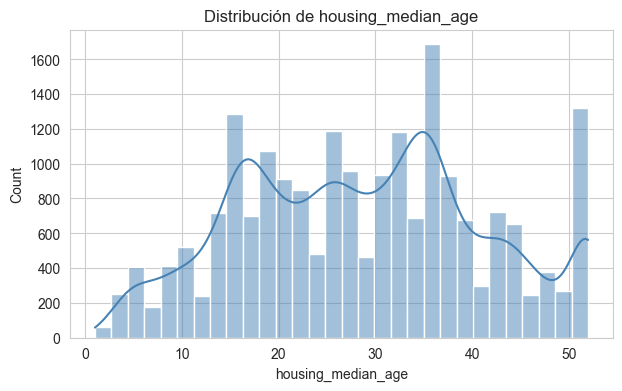

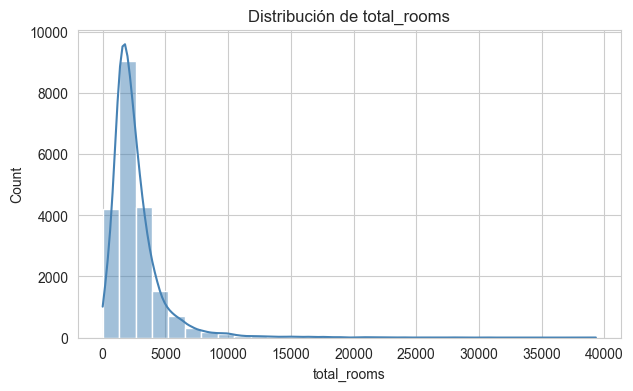

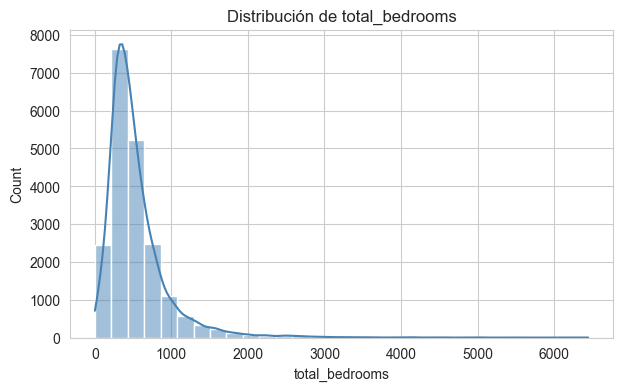

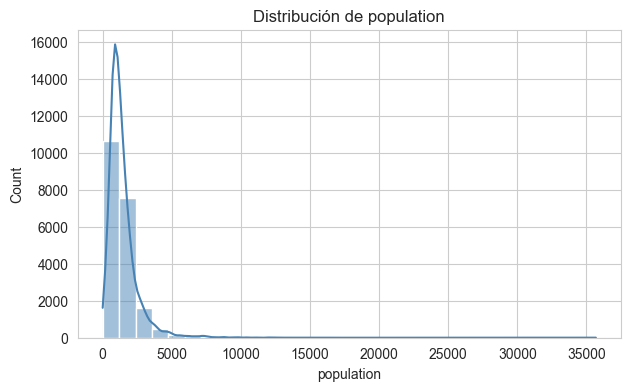

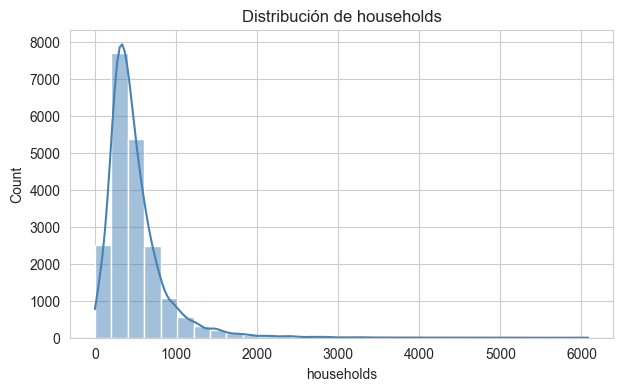

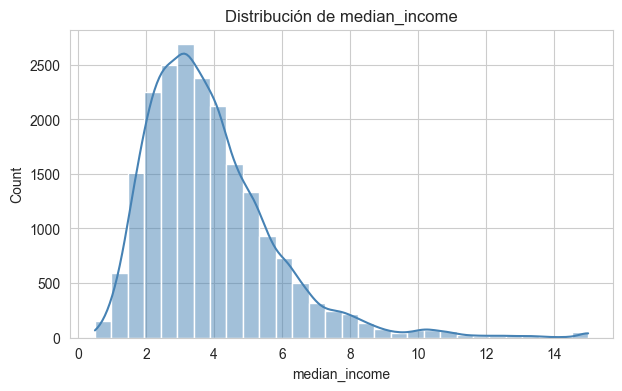

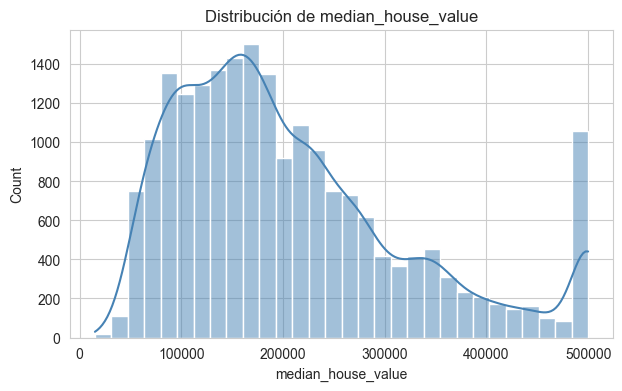

In [9]:
cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

for col in cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribución de {col}')
    plt.show()

In [10]:
group_mean = df.groupby('ocean_proximity')[cols].mean()
display(group_mean)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


### Diagrama de caja

El boxplot permite detectar valores extremos y comparar la distribución de una variable numérica entre categorías. Aquí miramos cómo cambia el valor de la vivienda según la cercanía al océano.

<Figure size 1400x600 with 0 Axes>

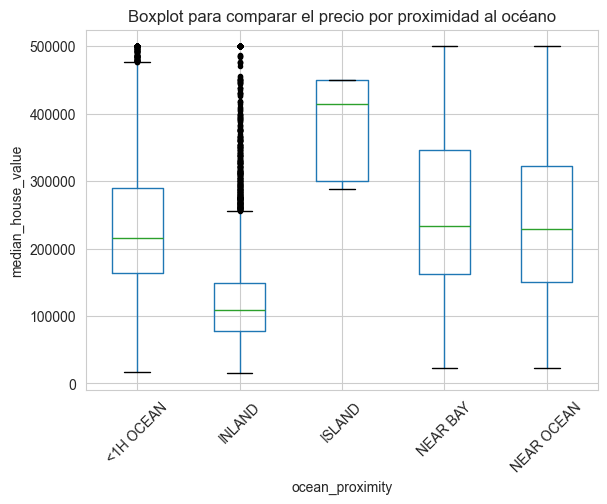

In [11]:
plt.figure(figsize=(14, 6))
df.boxplot(column='median_house_value', by='ocean_proximity', sym='k.')
plt.title('Boxplot para comparar el precio por proximidad al océano')
plt.suptitle('')
plt.xlabel('ocean_proximity')
plt.ylabel('median_house_value')
plt.xticks(rotation=45)
plt.show()

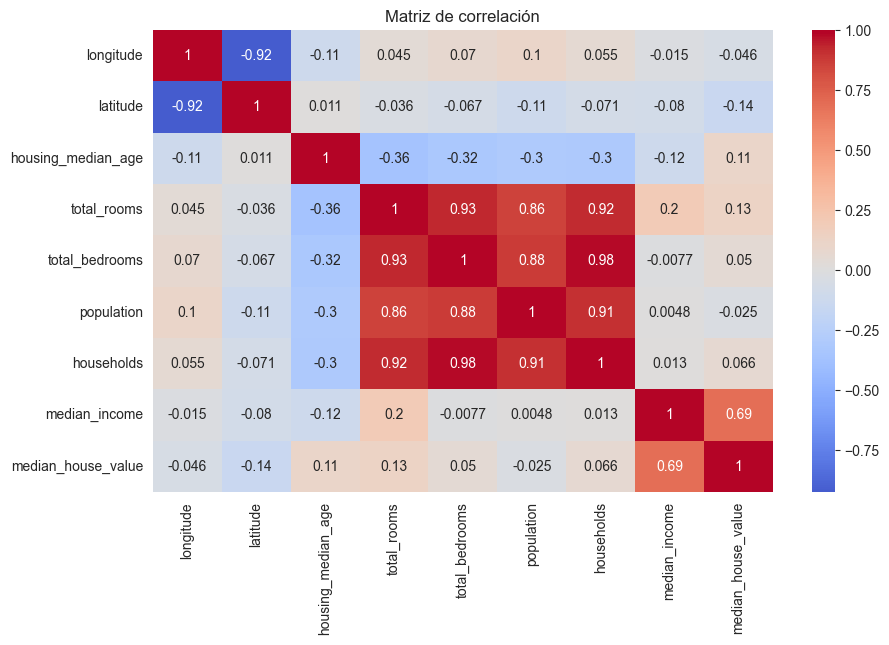

In [12]:
corr_matrix = df.drop(columns=['ocean_proximity']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

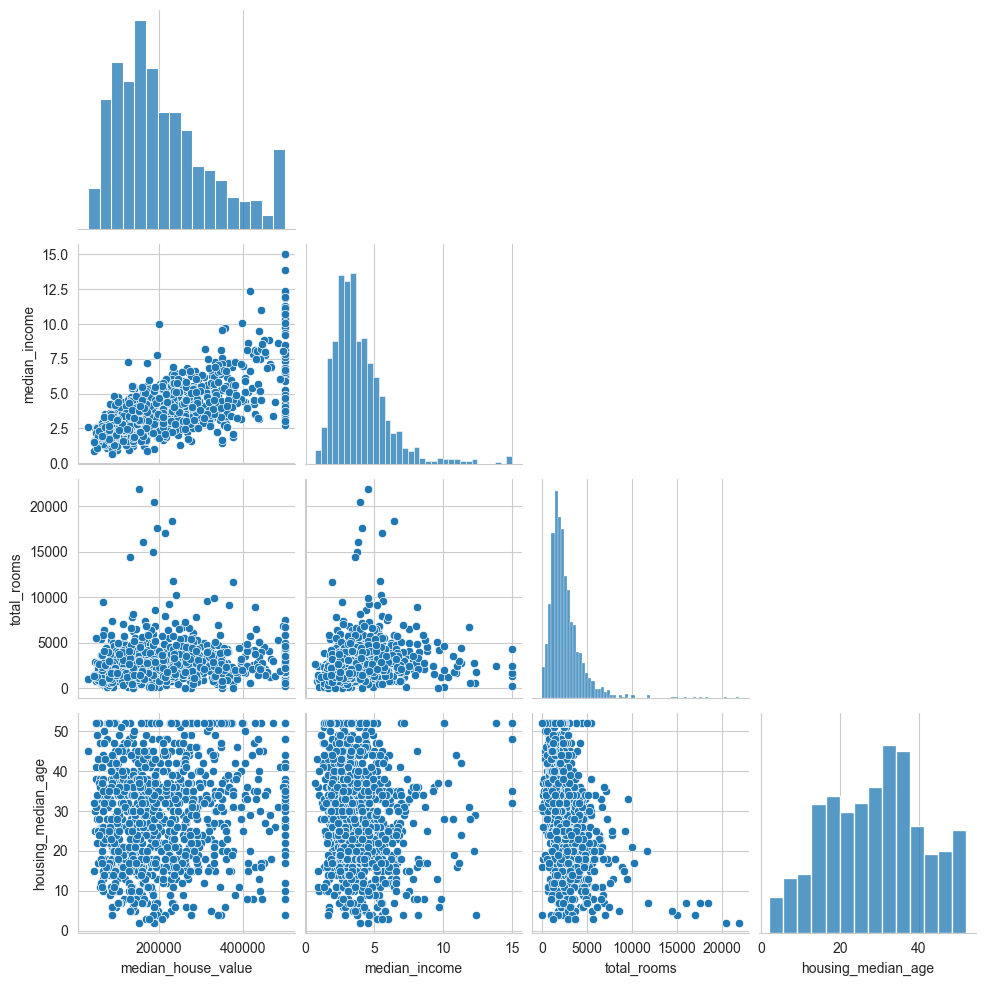

In [13]:
pair_cols = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
sns.pairplot(df[pair_cols].sample(1000, random_state=42), diag_kind='hist', corner=True)
plt.show()

## 5. Partición del dataset

Para evitar sesgo de muestreo, se recomienda estratificar la división usando una categoría de ingreso. Esto hace que train y test conserven proporciones similares de zonas de bajo, medio y alto ingreso.

In [15]:
df['income_cat'] = pd.cut(
    df['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index].copy()
    strat_test_set = df.loc[test_index].copy()

print('Tamaño train estratificado:', len(strat_train_set))
print('Tamaño test estratificado:', len(strat_test_set))

def income_cat_proportions(data):
    return data['income_cat'].value_counts() / len(data)

compare_props = pd.DataFrame({
    'Overall': income_cat_proportions(df),
    'Stratified': income_cat_proportions(strat_test_set),
    'Random': income_cat_proportions(train_test_split(df, test_size=0.2, random_state=7)[1]),
}).sort_index()
compare_props['Rand. %error'] = abs(100 * compare_props['Random'] / compare_props['Overall'] - 100)
compare_props['Strat. %error'] = abs(100 * compare_props['Stratified'] / compare_props['Overall'] - 100)
display(compare_props)

Tamaño train estratificado: 16512
Tamaño test estratificado: 4128


,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.039971,0.364964,0.364964
2,0.318847,0.318798,0.297481,6.701109,0.015195
3,0.350581,0.350533,0.358043,2.128248,0.013820
4,0.176308,0.176357,0.188953,7.172300,0.027480
5,0.114438,0.114341,0.115552,0.973751,0.084674


## 6. Feature Engineering

Construimos variables derivadas que capturan densidad y composición del hogar. Estas variables suelen ser más informativas que las columnas originales por separado.

In [16]:
for frame in [strat_train_set, strat_test_set]:
    frame['rooms_per_household'] = frame['total_rooms'] / frame['households']
    frame['bedrooms_per_room'] = frame['total_bedrooms'] / frame['total_rooms']
    frame['population_per_household'] = frame['population'] / frame['households']

display(strat_train_set[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

,rooms_per_household,bedrooms_per_room,population_per_household
12655,5.485836,0.205784,3.168555
15502,6.927083,0.160714,2.623698
2908,5.393333,0.191595,2.223333
14053,3.886128,0.276505,1.859213
20496,6.096552,0.182692,3.167241


## 7. Preparación de datos

Ahora separamos variables numéricas y categóricas, imputamos valores faltantes, codificamos `ocean_proximity` y estandarizamos los atributos numéricos.

Este paso automatiza la limpieza y evita fuga de información entre entrenamiento y prueba.

In [17]:
housing = strat_train_set.drop('median_house_value', axis=1).copy()
housing_labels = strat_train_set['median_house_value'].copy()

housing_num = housing.drop('ocean_proximity', axis=1)
num_attribs = list(housing_num.columns)
cat_attribs = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)
print('Forma del dataset preparado:', housing_prepared.shape)

Forma del dataset preparado: (16512, 17)


## 8. Modelo base: regresión lineal

Primero entrenamos un modelo lineal como línea base. Este modelo es simple e interpretable, pero puede quedarse corto si las relaciones no son lineales.

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

sample_data = housing.iloc[:5]
sample_labels = housing_labels.iloc[:5]
sample_prepared = full_pipeline.transform(sample_data)
sample_pred = lin_reg.predict(sample_prepared)

print('Predicciones ejemplo:')
print(sample_pred)
print('Valores reales:')
print(sample_labels.values)

Predicciones ejemplo:
[ 81207.67117047 316596.26559522 142015.72645295 185414.09044777
 234487.57732276]
Valores reales:
[ 72100. 279600.  82700. 112500. 238300.]


In [19]:
lin_predictions = lin_reg.predict(housing_prepared)
lin_rmse = mean_squared_error(housing_labels, lin_predictions, squared=False)
lin_mae = mean_absolute_error(housing_labels, lin_predictions)
lin_r2 = r2_score(housing_labels, lin_predictions)

print(f'RMSE entrenamiento: {lin_rmse:.2f}')
print(f'MAE entrenamiento: {lin_mae:.2f}')
print(f'R2 entrenamiento: {lin_r2:.4f}')

RMSE entrenamiento: 67795.90
MAE entrenamiento: 49133.70
R2 entrenamiento: 0.6566


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 9. Evaluación en test

La evaluación debe realizarse sobre datos no usados en el ajuste. El score de un modelo de regresión lineal aquí se interpreta principalmente mediante $R^2$, mientras que RMSE y MAE dan la magnitud del error en la escala de la variable objetivo.

RMSE test: 66638.45
MAE test: 49171.10
R2 test: 0.6593


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


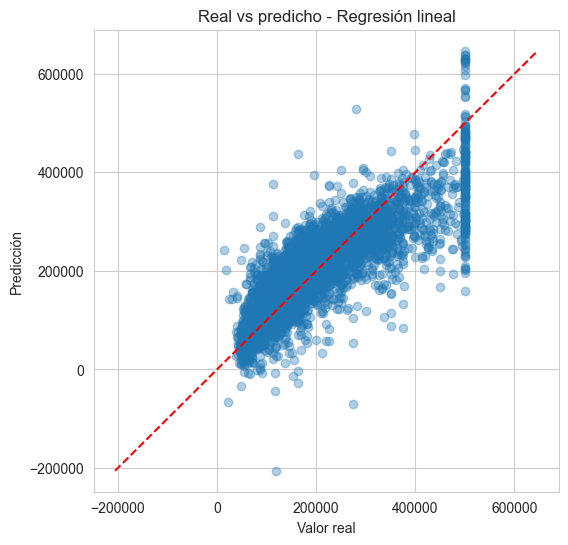

In [20]:
housing_test = strat_test_set.drop('median_house_value', axis=1).copy()
housing_test_labels = strat_test_set['median_house_value'].copy()
housing_test_prepared = full_pipeline.transform(housing_test)

test_predictions = lin_reg.predict(housing_test_prepared)
test_rmse = mean_squared_error(housing_test_labels, test_predictions, squared=False)
test_mae = mean_absolute_error(housing_test_labels, test_predictions)
test_r2 = r2_score(housing_test_labels, test_predictions)

print(f'RMSE test: {test_rmse:.2f}')
print(f'MAE test: {test_mae:.2f}')
print(f'R2 test: {test_r2:.4f}')

plt.figure(figsize=(6, 6))
plt.scatter(housing_test_labels, test_predictions, alpha=0.35)
lims = [min(housing_test_labels.min(), test_predictions.min()), max(housing_test_labels.max(), test_predictions.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Real vs predicho - Regresión lineal')
plt.show()

## 10. Comparación con otro modelo

Como el problema puede tener relaciones no lineales e interacciones complejas, probamos un modelo de ensamble. Aquí usamos un random forest regressor como referencia comparativa.

In [24]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(housing_prepared, housing_labels)

rf_test_predictions = rf_reg.predict(housing_test_prepared)
rf_rmse = mean_squared_error(housing_test_labels, rf_test_predictions, squared=False)
rf_mae = mean_absolute_error(housing_test_labels, rf_test_predictions)
rf_r2 = r2_score(housing_test_labels, rf_test_predictions)

print(f'RMSE random forest test: {rf_rmse:.2f}')
print(f'MAE random forest test: {rf_mae:.2f}')
print(f'R2 random forest test: {rf_r2:.4f}')

comparison = pd.DataFrame({'Modelo': ['Lineal', 'Random Forest'],
    'RMSE': [test_rmse, rf_rmse],
    'MAE': [test_mae, rf_mae],
    'R2': [test_r2, rf_r2] })
display(comparison)

RMSE random forest test: 48143.01
MAE random forest test: 31710.39
R2 random forest test: 0.8222


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Modelo,RMSE,MAE,R2
0,Lineal,66638.450912,49171.101953,0.659278
1,Random Forest,48143.006950,31710.385925,0.822165


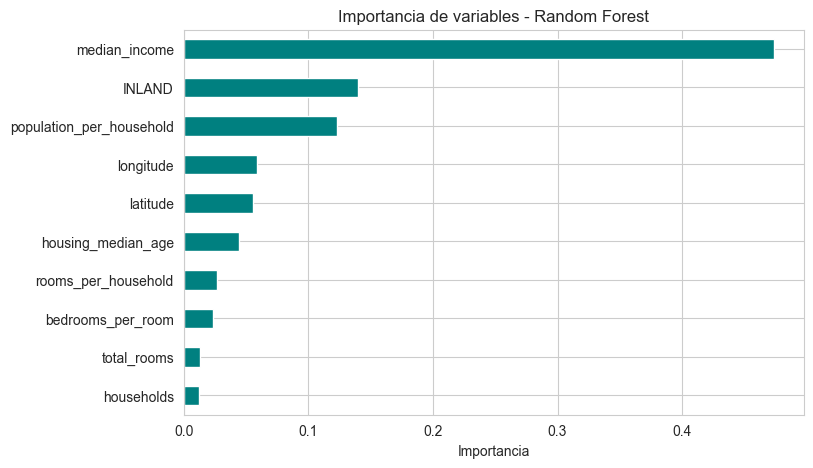

In [25]:
importances = rf_reg.feature_importances_
feature_names = num_attribs + list(full_pipeline.named_transformers_['cat'].named_steps['onehot'].categories_[0])
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.head(10).sort_values().plot(kind='barh', color='teal')
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.show()

## 11. Interpretación de resultados

- El score $R^2$ mide la proporción de variabilidad explicada por el modelo.
- RMSE y MAE expresan el tamaño del error en la escala original del objetivo.
- La comparación entre regresión lineal y random forest muestra si una relación más flexible mejora el ajuste.
- La automatización con pipelines evita errores manuales y deja listo el flujo completo para nuevos datos.

## 12. Automatización con pipeline

El pipeline integra preprocesamiento y modelo en una sola estructura reproducible. Esto facilita el entrenamiento, la validación y el despliegue posterior.

In [26]:
full_regression_pipeline = Pipeline([
    ('preprocess', full_pipeline),
    ('model', LinearRegression())
])

scores = cross_val_score(full_regression_pipeline, strat_train_set.drop('median_house_value', axis=1), strat_train_set['median_house_value'], scoring='r2', cv=5)
print('Scores R2 por pliegue:', np.round(scores, 4))
print(f'R2 medio: {scores.mean():.4f}')
print(f'Desviación estándar: {scores.std():.4f}')

Scores R2 por pliegue: [0.6576 0.6566 0.6462 0.6459 0.6628]
R2 medio: 0.6538
Desviación estándar: 0.0067


## Conclusiones

1. El análisis inicial permite entender variables, categorías y posibles problemas de calidad de datos.
2. La estratificación asegura que el conjunto de prueba conserve la distribución de la variable de ingreso.
3. La preparación con imputación, codificación y escalamiento es esencial para obtener modelos robustos.
4. La regresión lineal sirve como línea base, pero modelos más flexibles pueden mejorar el desempeño.
5. Los pipelines encapsulan todo el flujo y hacen el análisis reproducible y más seguro.